# Análise integrada: GDP per capita × Obesidade

Este notebook dá continuidade a `analise_gdp.ipynb` e `analise_obesity.ipynb` e atende aos itens de **Próximos Passos** do README:

- cruzamento dos datasets;
- scatter plot e heatmap;
- correlações de Pearson e Spearman;
- identificação de comportamentos atípicos;
- conclusões interpretáveis.

> Critério: usamos obesidade de **Both sexes**. Como o GDP está disponível a cada cinco anos e a obesidade anualmente, o GDP é interpolado linearmente entre observações do mesmo país. Não há extrapolação além de 2011, último ano do dataset de GDP. Correlação descreve associação, não causalidade.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('ggplot')

BASE = Path('arquivos_base')
assert (BASE / 'gdp.csv').exists(), 'Execute o notebook a partir da raiz do projeto.'
assert (BASE / 'obesity_cleaned.csv').exists(), 'Arquivo de obesidade não encontrado.'

## 1. Leitura e limpeza

A limpeza reaproveita as decisões dos notebooks originais, mas torna as conversões mais robustas: remove espaços dos nomes de colunas, extrai o ano da data e captura numericamente o valor inicial da coluna textual de obesidade.

In [2]:
gdp = pd.read_csv(BASE / 'gdp.csv')
gdp.columns = gdp.columns.str.strip()
gdp['Year'] = pd.to_datetime(gdp['Year'], errors='coerce').dt.year
gdp['GDP_pp'] = pd.to_numeric(
    gdp['GDP_pp'].astype(str).str.replace(',', '', regex=False), errors='coerce'
)
gdp = gdp.dropna(subset=['Country', 'Region', 'Year', 'GDP_pp'])
gdp['Year'] = gdp['Year'].astype(int)

obesity = pd.read_csv(BASE / 'obesity_cleaned.csv')
obesity = obesity.drop(columns=['Unnamed: 0'], errors='ignore')
obesity['Obesity_f'] = pd.to_numeric(
    obesity['Obesity (%)'].astype(str).str.extract(r'([0-9]+(?:\.[0-9]+)?)')[0],
    errors='coerce'
)
obesity = obesity.loc[obesity['Sex'].eq('Both sexes'), ['Country', 'Year', 'Obesity_f']]
obesity = obesity.dropna().drop_duplicates(['Country', 'Year'])
obesity['Year'] = obesity['Year'].astype(int)

pd.DataFrame({
    'dataset': ['GDP', 'Obesidade (ambos os sexos)'],
    'linhas': [len(gdp), len(obesity)],
    'paises': [gdp['Country'].nunique(), obesity['Country'].nunique()],
    'ano_inicial': [gdp['Year'].min(), obesity['Year'].min()],
    'ano_final': [gdp['Year'].max(), obesity['Year'].max()]
})

,dataset,linhas,paises,ano_inicial,ano_final
0,GDP,4419,193,1901,2011
1,Obesidade (ambos os sexos),8022,191,1975,2016


## 2. Padronização dos países e interpolação anual

O mapa abaixo contém apenas equivalências verificáveis entre as nomenclaturas dos arquivos. Depois, cada série de GDP é interpolada anualmente entre pontos conhecidos.

In [3]:
country_aliases = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Brunei Darussalam': 'Brunei',
    'Cabo Verde': 'Cape Verde',
    'Congo': 'Congo, Rep.',
    'Czechia': 'Czech Rep.',
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Democratic People's Republic of Korea": 'Korea, Dem. Rep.',
    'Eswatini': 'Swaziland',
    'Iran (Islamic Republic of)': 'Iran',
    "Lao People's Democratic Republic": 'Laos',
    'Micronesia (Federated States of)': 'Micronesia, Fed. Sts.',
    'Republic of Korea': 'Korea, Rep.',
    'Republic of Moldova': 'Moldova',
    'Republic of North Macedonia': 'Macedonia, FYR',
    'Russian Federation': 'Russia',
    'Slovakia': 'Slovak Republic',
    'Syrian Arab Republic': 'Syria',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania': 'Tanzania',
    'United States of America': 'United States',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Yemen': 'Yemen, Rep.'
}
obesity['Country_original'] = obesity['Country']
obesity['Country'] = obesity['Country'].replace(country_aliases)

def interpolate_country(group):
    group = group.groupby('Year', as_index=True)['GDP_pp'].mean().sort_index()
    annual_index = pd.Index(range(group.index.min(), group.index.max() + 1), name='Year')
    return group.reindex(annual_index).interpolate(method='linear')

annual_parts = []
for (country, region), group in gdp.groupby(['Country', 'Region'], sort=False):
    annual = interpolate_country(group).rename('GDP_pp').reset_index()
    annual['Country'] = country
    annual['Region'] = region
    annual_parts.append(annual)

gdp_annual = pd.concat(annual_parts, ignore_index=True)
gdp_annual = gdp_annual[['Country', 'Region', 'Year', 'GDP_pp']]

In [4]:
merged = obesity.merge(gdp_annual, on=['Country', 'Year'], how='inner', validate='one_to_one')
merged = merged.sort_values(['Country', 'Year']).reset_index(drop=True)

unmatched_obesity = sorted(set(obesity['Country']) - set(gdp['Country']))
coverage = pd.Series({
    'linhas_cruzadas': len(merged),
    'paises_cruzados': merged['Country'].nunique(),
    'ano_inicial_comum': merged['Year'].min(),
    'ano_final_comum': merged['Year'].max(),
    'paises_obesidade_sem_GDP': len(unmatched_obesity)
}, name='cobertura')
display(coverage.to_frame())
print('Países da base de obesidade sem correspondência no GDP:', unmatched_obesity)
display(merged.head())

,cobertura
linhas_cruzadas,6835
paises_cruzados,185
ano_inicial_comum,1975
ano_final_comum,2011
paises_obesidade_sem_GDP,6


Países da base de obesidade sem correspondência no GDP: ['Central African Republic', 'Cook Islands', 'Democratic Republic of the Congo', 'Dominican Republic', 'Niue', 'Sudan (former)']


,Country,Year,Obesity_f,Country_original,Region,GDP_pp
0,Afghanistan,1975,0.50,Afghanistan,"Middle East, North Africa, and Greater Arabia",847.69
1,Afghanistan,1976,0.50,Afghanistan,"Middle East, North Africa, and Greater Arabia",866.19
2,Afghanistan,1977,0.60,Afghanistan,"Middle East, North Africa, and Greater Arabia",872.32
3,Afghanistan,1978,0.60,Afghanistan,"Middle East, North Africa, and Greater Arabia",878.46
4,Afghanistan,1979,0.60,Afghanistan,"Middle East, North Africa, and Greater Arabia",884.59


## 3. Correlação estatística

- **Pearson** mede associação linear.
- **Spearman** mede associação monotônica por postos e é menos sensível à forte assimetria do GDP.

A análise empilhada usa todos os país-anos e pode misturar diferenças entre países com tendência temporal. Por isso também mostramos o último ano comum e correlações anuais.

In [5]:
def correlations(frame):
    valid = frame[['GDP_pp', 'Obesity_f']].dropna()
    return pd.Series({
        'Pearson': valid['GDP_pp'].corr(valid['Obesity_f']),
        'Spearman': valid['GDP_pp'].rank().corr(valid['Obesity_f'].rank()),
        'N': len(valid)
    })

latest_year = int(merged['Year'].max())
latest = merged.loc[merged['Year'].eq(latest_year)].copy()
correlation_summary = pd.DataFrame({
    'Todos os país-anos': correlations(merged),
    f'Retrato de {latest_year}': correlations(latest)
}).T
correlation_summary

,Pearson,Spearman,N
Todos os país-anos,0.37,0.65,"6,835.00"
Retrato de 2011,0.32,0.57,184.00


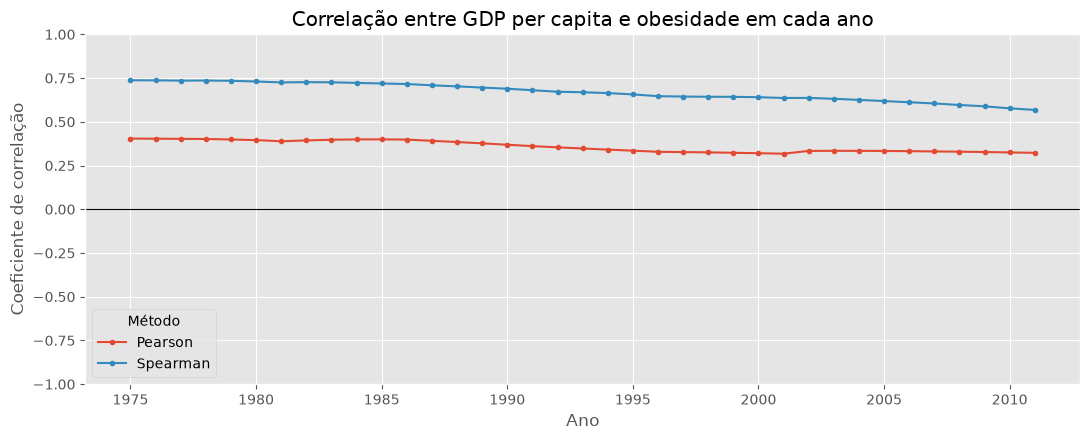

In [6]:
yearly_corr = (
    merged.groupby('Year')
    .apply(lambda x: correlations(x)[['Pearson', 'Spearman']], include_groups=False)
)

fig, ax = plt.subplots(figsize=(11, 4.5))
yearly_corr.plot(ax=ax, marker='o', markersize=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Correlação entre GDP per capita e obesidade em cada ano',
       xlabel='Ano', ylabel='Coeficiente de correlação', ylim=(-1, 1))
ax.legend(title='Método')
plt.tight_layout()
plt.show()

## 4. Visualizações comparativas

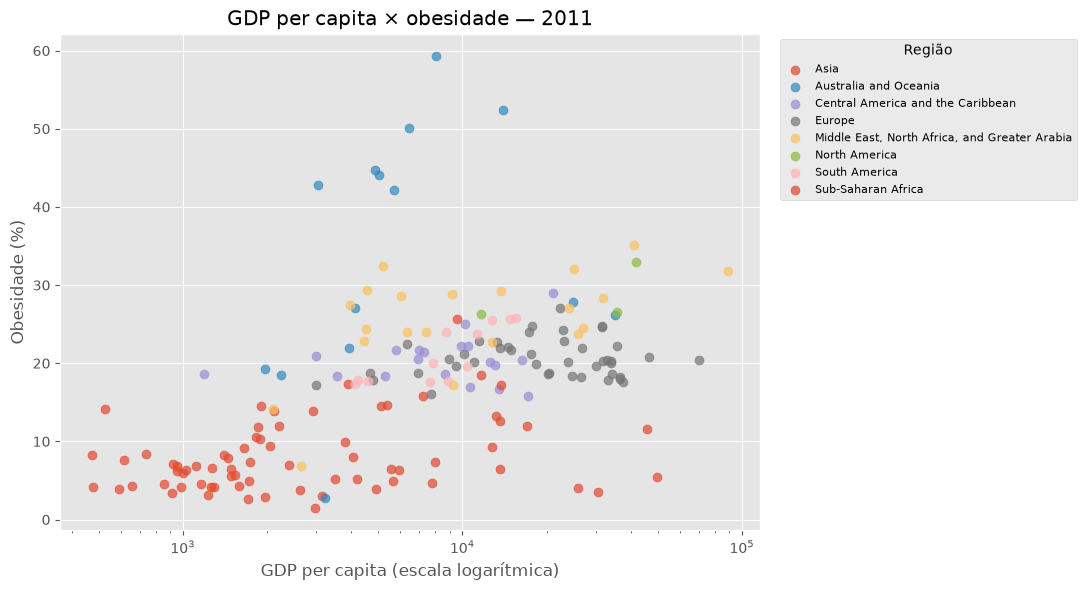

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
for region, group in latest.groupby('Region'):
    ax.scatter(group['GDP_pp'], group['Obesity_f'], alpha=0.72, s=42, label=region)
ax.set_xscale('log')
ax.set(title=f'GDP per capita × obesidade — {latest_year}',
       xlabel='GDP per capita (escala logarítmica)', ylabel='Obesidade (%)')
ax.legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

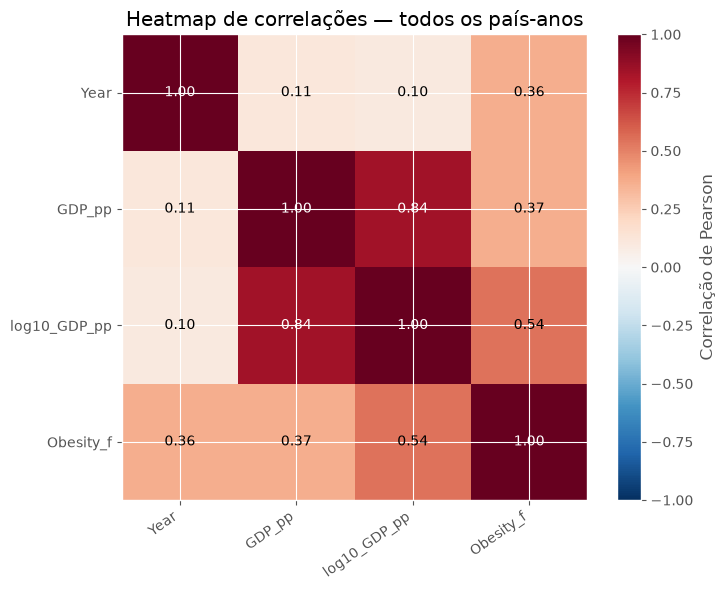

In [8]:
numeric = merged[['Year', 'GDP_pp', 'Obesity_f']].copy()
numeric['log10_GDP_pp'] = np.log10(numeric['GDP_pp'])
corr_matrix = numeric[['Year', 'GDP_pp', 'log10_GDP_pp', 'Obesity_f']].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
image = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
labels = corr_matrix.columns
ax.set_xticks(range(len(labels)), labels, rotation=35, ha='right')
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                color='white' if abs(value) > .55 else 'black')
fig.colorbar(image, ax=ax, label='Correlação de Pearson')
ax.set_title('Heatmap de correlações — todos os país-anos')
plt.tight_layout()
plt.show()

,paises,GDP_medio,obesidade_media
Region,,,
Asia,26,"9,684.01",7.42
Sub-Saharan Africa,44,"3,287.19",8.46
Central America and the Caribbean,19,"9,653.53",20.45
Europe,43,"22,756.79",20.64
South America,12,"9,225.63",21.04
"Middle East, North Africa, and Greater Arabia",23,"15,583.48",23.72
North America,3,"29,703.06",28.63
Australia and Oceania,14,"8,759.39",34.24


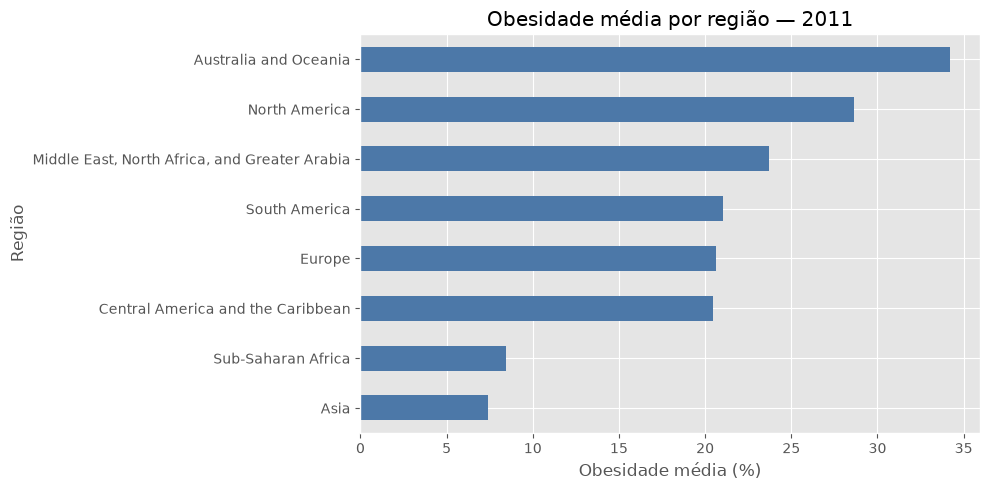

In [9]:
region_summary = (
    latest.groupby('Region')
    .agg(paises=('Country', 'nunique'), GDP_medio=('GDP_pp', 'mean'),
         obesidade_media=('Obesity_f', 'mean'))
    .sort_values('obesidade_media')
)
display(region_summary)

fig, ax = plt.subplots(figsize=(10, 5))
region_summary['obesidade_media'].plot.barh(ax=ax, color='#4C78A8')
ax.set(title=f'Obesidade média por região — {latest_year}',
       xlabel='Obesidade média (%)', ylabel='Região')
plt.tight_layout()
plt.show()

## 5. Países atípicos

A regressão simples abaixo estima a obesidade esperada a partir de `log10(GDP)`. O resíduo é a diferença entre o valor observado e o estimado. Resíduos positivos altos indicam obesidade acima da tendência econômica; negativos indicam obesidade abaixo dela. É um diagnóstico descritivo, não um modelo causal.

In [10]:
x = np.log10(latest['GDP_pp'].to_numpy())
y = latest['Obesity_f'].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
latest['Obesity_estimada'] = slope * x + intercept
latest['Residuo'] = latest['Obesity_f'] - latest['Obesity_estimada']
columns = ['Country_original', 'Region', 'GDP_pp', 'Obesity_f', 'Obesity_estimada', 'Residuo']

print('Obesidade mais acima da tendência associada ao GDP:')
display(latest.nlargest(5, 'Residuo')[columns].round(2))
print('Obesidade mais abaixo da tendência associada ao GDP:')
display(latest.nsmallest(5, 'Residuo')[columns].round(2))

Obesidade mais acima da tendência associada ao GDP:


,Country_original,Region,GDP_pp,Obesity_f,Obesity_estimada,Residuo
4328,Nauru,Australia and Oceania,"8,051.77",59.30,18.32,40.98
3884,Marshall Islands,Australia and Oceania,"6,464.55",50.10,17.38,32.72
4698,Palau,Australia and Oceania,"13,980.82",52.40,20.70,31.70
3144,Kiribati,Australia and Oceania,"3,036.74",42.80,14.13,28.67
6178,Tonga,Australia and Oceania,"4,885.71",44.70,16.17,28.53


Obesidade mais abaixo da tendência associada ao GDP:


,Country_original,Region,GDP_pp,Obesity_f,Obesity_estimada,Residuo
5512,Singapore,Asia,"49,587.16",5.50,26.15,-20.65
2996,Japan,Asia,"30,593.47",3.50,24.07,-20.57
3218,Republic of Korea,Asia,"25,799.12",4.00,23.33,-19.33
924,Brunei Darussalam,Asia,"45,764.67",11.60,25.80,-14.20
1886,Equatorial Guinea,Sub-Saharan Africa,"13,603.34",6.50,20.58,-14.08


## 6. Conclusões geradas a partir dos resultados

In [11]:
pearson_all = correlation_summary.loc['Todos os país-anos', 'Pearson']
spearman_all = correlation_summary.loc['Todos os país-anos', 'Spearman']
pearson_latest = correlation_summary.loc[f'Retrato de {latest_year}', 'Pearson']
top_region = region_summary['obesidade_media'].idxmax()
bottom_region = region_summary['obesidade_media'].idxmin()

print(f'''CONCLUSÕES
1. Há associação positiva entre GDP per capita e obesidade no conjunto: Pearson = {pearson_all:.2f} e Spearman = {spearman_all:.2f}.
2. No retrato transversal de {latest_year}, Pearson = {pearson_latest:.2f}. A comparação anual ajuda a separar esse padrão das mudanças ao longo do tempo.
3. Em {latest_year}, {top_region} apresenta a maior obesidade média regional, enquanto {bottom_region} apresenta a menor.
4. Os resíduos mostram exceções importantes: riqueza, sozinha, não explica toda a variação entre países. Região, alimentação, urbanização, políticas públicas e desigualdade são possíveis fatores adicionais, mas não são testados nestes dados.
5. A interpolação possibilita o cruzamento anual, porém cria estimativas entre observações de GDP. Além disso, o resultado não deve ser interpretado como efeito causal e não é ponderado pela população.
6. Próxima extensão recomendada: incorporar população, desigualdade, urbanização e intervalos de incerteza da medida de obesidade em um modelo multivariado.''')

CONCLUSÕES
1. Há associação positiva entre GDP per capita e obesidade no conjunto: Pearson = 0.37 e Spearman = 0.65.
2. No retrato transversal de 2011, Pearson = 0.32. A comparação anual ajuda a separar esse padrão das mudanças ao longo do tempo.
3. Em 2011, Australia and Oceania apresenta a maior obesidade média regional, enquanto Asia apresenta a menor.
4. Os resíduos mostram exceções importantes: riqueza, sozinha, não explica toda a variação entre países. Região, alimentação, urbanização, políticas públicas e desigualdade são possíveis fatores adicionais, mas não são testados nestes dados.
5. A interpolação possibilita o cruzamento anual, porém cria estimativas entre observações de GDP. Além disso, o resultado não deve ser interpretado como efeito causal e não é ponderado pela população.
6. Próxima extensão recomendada: incorporar população, desigualdade, urbanização e intervalos de incerteza da medida de obesidade em um modelo multivariado.
